In [12]:
# =============================================================================
# ЧАСТЬ 1: ПОДГОТОВКА ДАННЫХ ДЛЯ FINBERT
# =============================================================================
import os
import re
import pandas as pd
from datasets import load_dataset

# ---------- НАСТРОЙКИ ----------
TICKER = "aapl"  # тикер компании в нижнем регистре
OUTPUT_FILE = "prepared_tweets.csv"  # куда сохраним результат
# ------------------------------

def extract_tweets_with_dates(text_block):
    """Извлекает из блока text отдельные твиты с их датами."""
    if not isinstance(text_block, str):
        return []
    tweets = []
    for line in text_block.split('\n'):
        line = line.strip()
        if not line:
            continue
        # Ищем дату в начале строки вида YYYY-MM-DD:
        match = re.match(r'(\d{4}-\d{2}-\d{2}):', line)
        if match:
            date_str = match.group(1)
            tweet_text = line[len(match.group(0)):].strip()
            if tweet_text and f"${TICKER}" in tweet_text.lower():
                tweets.append({'date': date_str, 'tweet': tweet_text})
    return tweets

print("Загрузка датасета TheFinAI/flare-sm-bigdata...")
# Учитываем, что раздел называется 'valid', а не 'validation'
splits = ['train', 'validation', 'test']
all_tweets = []

for split in splits:
    try:
        dataset = load_dataset("TheFinAI/flare-sm-bigdata", split=split)
        print(f"  Обработка {split} ({len(dataset)} записей)...")
        for example in dataset:
            # Проверяем, что тикер упоминается в запросе
            query = example.get('query', '')
            if f"${TICKER}" not in query.lower():
                continue
            # Извлекаем твиты с датами
            tweets = extract_tweets_with_dates(example.get('text', ''))
            all_tweets.extend(tweets)
    except Exception as e:
        print(f"  ⚠️ Не удалось загрузить {split}: {e}")

if not all_tweets:
    print(f"❌ Не найдено твитов для тикера ${TICKER}. Попробуйте другой тикер (например, 'csco').")
    exit()

# Сохраняем в CSV
df_tweets = pd.DataFrame(all_tweets)
df_tweets.to_csv(OUTPUT_FILE, index=False, encoding='utf-8')
print(f"\n✅ Подготовлено {len(df_tweets)} твитов для FinBERT.")
print(f"   Диапазон дат: {df_tweets['date'].min()} — {df_tweets['date'].max()}")
print(f"   Файл сохранён: {OUTPUT_FILE}")

Загрузка датасета TheFinAI/flare-sm-bigdata...
  Обработка train (4897 записей)...
  Обработка validation (798 записей)...
  Обработка test (1472 записей)...

✅ Подготовлено 5465 твитов для FinBERT.
   Диапазон дат: 2020-03-18 — 2020-06-30
   Файл сохранён: prepared_tweets.csv


In [ ]:
# =============================================================================
# ЧАСТЬ 2: FINBERT И ПОДГОТОВКА ДАННЫХ ДЛЯ SARIMA (ИСПРАВЛЕННАЯ)
# =============================================================================
import pandas as pd
import numpy as np
from transformers import pipeline
from tqdm import tqdm
import yfinance as yf
from datetime import timedelta

# ---------- НАСТРОЙКИ ----------
TWEETS_FILE = "prepared_tweets.csv"
TICKER_YF = "AAPL"   # или "TSLA", "CSCO" и т.д.
TEST_DAYS = 30
# ------------------------------

# 1. Загружаем твиты
df = pd.read_csv(TWEETS_FILE)
df['date'] = pd.to_datetime(df['date'])
print(f"Загружено твитов: {len(df)}")

# 2. Загружаем FinBERT с возвратом всех вероятностей
print("\nЗагрузка FinBERT...")
sentiment_pipe = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    device=-1,
    top_k=None   # вместо return_all_scores=True в новых версиях transformers
)

# 3. Функция для P(pos) - P(neg)
def get_sentiment_score(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0
    try:
        # Получаем список словарей [{label:..., score:...}, ...]
        result = sentiment_pipe(text[:512])[0]
        # Если это список словарей (при top_k=None)
        if isinstance(result, list):
            scores = {item['label']: item['score'] for item in result}
        elif isinstance(result, dict):
            # На случай, если модель возвращает один результат
            label = result['label']
            score = result['score']
            if label == 'positive':
                return score
            elif label == 'negative':
                return -score
            else:
                return 0.0
        else:
            return 0.0
        pos = scores.get('positive', 0.0)
        neg = scores.get('negative', 0.0)
        return pos - neg
    except Exception as e:
        # print(f"Ошибка: {e}")  # раскомментируйте для отладки
        return 0.0

# 4. Применяем FinBERT
print("Анализ тональности...")
tqdm.pandas(desc="FinBERT")
df['sentiment'] = df['tweet'].progress_apply(get_sentiment_score)

# 5. Агрегация по дням (средняя тональность)
daily = df.groupby('date')['sentiment'].mean().reset_index()
daily = daily.sort_values('date')
print(f"Уникальных дней с твитами: {len(daily)}")

# 6. Загружаем цены акций
start = daily['date'].min()
end = daily['date'].max() + timedelta(days=TEST_DAYS + 5)
print(f"\nЗагрузка цен {TICKER_YF} с {start.date()} по {end.date()}...")
stock = yf.download(TICKER_YF, start=start, end=end, progress=False)
prices = stock['Close'].copy()
prices.name = 'price'
prices.index = pd.to_datetime(prices.index)

# 7. Формируем общий DataFrame
data = pd.DataFrame(index=prices.index)
data['price'] = prices

daily['target_date'] = daily['date'] + timedelta(days=1)
data = data.merge(
    daily[['target_date', 'sentiment']].rename(columns={'target_date': 'date'}),
    left_index=True, right_on='date', how='left'
).set_index('date')
data['sentiment'] = data['sentiment'].fillna(0)
data = data.dropna(subset=['price'])

print(f"Итоговый DataFrame: {len(data)} торговых дней")
print(data.head())

data.to_csv("data_for_sarima.csv")
print("\n✅ Данные для SARIMA сохранены в data_for_sarima.csv")

Загружено твитов: 5465

Загрузка FinBERT...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 13411.63it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Анализ тональности...


FinBERT:   2%|▏         | 87/5465 [00:17<15:58,  5.61it/s]

In [ ]:
s = 0
for i in data['sentiment']:
    if i != 0:
        s += 1
print(s)

73


Загружено 96 дней
ADF тест: p-value = 0.9520
Ряд нестационарен → работаем с разностями
Train: 65 дней, Test: 30 дней

Обучение SARIMA (без новостей)...
Обучение SARIMAX (с FinBERT)...


c:\Users\Alex_Gal\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Alex_Gal\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Alex_Gal\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Alex_Gal\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is availa


Результаты на тестовом периоде:
SARIMA без новостей: MAE=$3.07, RMSE=$3.92
SARIMAX + FinBERT : MAE=$2.59, RMSE=$3.27


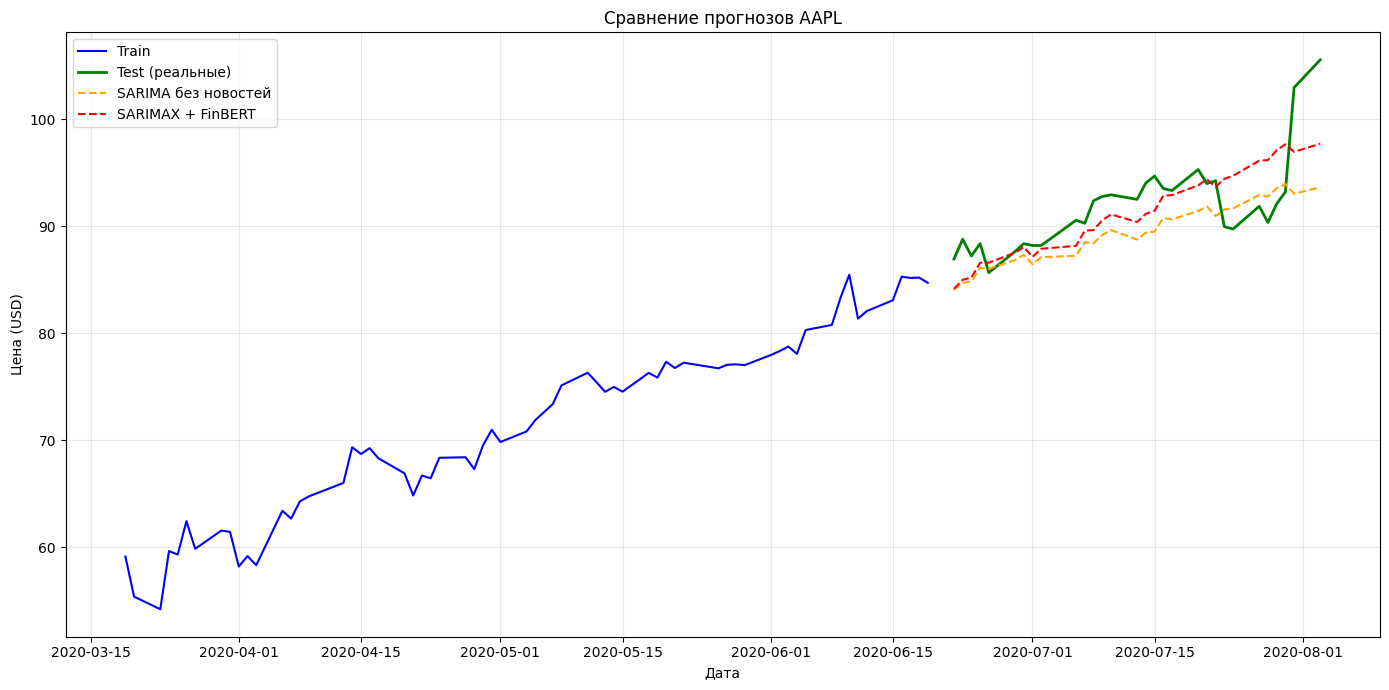

In [11]:
# =============================================================================
# ЧАСТЬ 3: SARIMA И СРАВНЕНИЕ МОДЕЛЕЙ
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ---------- НАСТРОЙКИ ----------
DATA_FILE = "data_for_sarima.csv"  # файл из Части 2
TEST_DAYS = 30                     # должно совпадать с Частью 2
# ------------------------------

# 1. Загружаем данные
data = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)
print(f"Загружено {len(data)} дней")

# 2. Проверка стационарности
result = adfuller(data['price'].dropna())
print(f"ADF тест: p-value = {result[1]:.4f}")
if result[1] > 0.05:
    print("Ряд нестационарен → работаем с разностями")
    data['target'] = data['price'].diff()
    use_diff = True
else:
    print("Ряд стационарен")
    data['target'] = data['price']
    use_diff = False
data = data.dropna()

# 3. Разделение на train/test
train = data.iloc[:-TEST_DAYS].copy()
test = data.iloc[-TEST_DAYS:].copy()
print(f"Train: {len(train)} дней, Test: {len(test)} дней")

# 4. Модель 1: чистая SARIMA
print("\nОбучение SARIMA (без новостей)...")
m1 = SARIMAX(train['target'], order=(1,1,1), seasonal_order=(1,1,1,7),
             enforce_stationarity=False, enforce_invertibility=False)
r1 = m1.fit(disp=False)
f1 = r1.get_forecast(steps=len(test))
pred1 = f1.predicted_mean

# 5. Модель 2: SARIMAX с сентиментом
print("Обучение SARIMAX (с FinBERT)...")
m2 = SARIMAX(train['target'], exog=train[['sentiment']],
             order=(1,1,1), seasonal_order=(1,1,1,7),
             enforce_stationarity=False, enforce_invertibility=False)
r2 = m2.fit(disp=False)
f2 = r2.get_forecast(steps=len(test), exog=test[['sentiment']])
pred2 = f2.predicted_mean

# 6. Восстановление цен (если были разности)
if use_diff:
    last_price = train['price'].iloc[-1]
    pred_price1 = last_price + pred1.cumsum()
    pred_price2 = last_price + pred2.cumsum()
else:
    pred_price1 = pred1
    pred_price2 = pred2

# 7. Метрики
def metrics(actual, pred, name):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    print(f"{name}: MAE=${mae:.2f}, RMSE=${rmse:.2f}")

print("\nРезультаты на тестовом периоде:")
metrics(test['price'], pred_price1, "SARIMA без новостей")
metrics(test['price'], pred_price2, "SARIMAX + FinBERT ")

# 8. График
plt.figure(figsize=(14,7))
plt.plot(train.index, train['price'], label='Train', color='blue')
plt.plot(test.index, test['price'], label='Test (реальные)', color='green', linewidth=2)
plt.plot(test.index, pred_price1, label='SARIMA без новостей', color='orange', linestyle='--')
plt.plot(test.index, pred_price2, label='SARIMAX + FinBERT', color='red', linestyle='--')
plt.title(f'Сравнение прогнозов {TICKER_YF}')
plt.xlabel('Дата'); plt.ylabel('Цена (USD)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()